Bắt đầu xử lý 4 file...

--- Đang xử lý file: alley_houses.csv ---
✅ Đã xử lý xong: alley_houses.csv (Xử lý toàn bộ 594 dòng dữ liệu!)

--- Đang xử lý file: land.csv ---
✅ Đã xử lý xong: land.csv (Xử lý toàn bộ 1275 dòng dữ liệu!)

--- Đang xử lý file: apartment.csv ---
✅ Đã xử lý xong: apartment.csv (Xử lý toàn bộ 96 dòng dữ liệu!)

--- Đang xử lý file: street_house.csv ---
✅ Đã xử lý xong: street_house.csv (Xử lý toàn bộ 1311 dòng dữ liệu!)

Đang gộp dữ liệu và vẽ biểu đồ Scatter Plot...


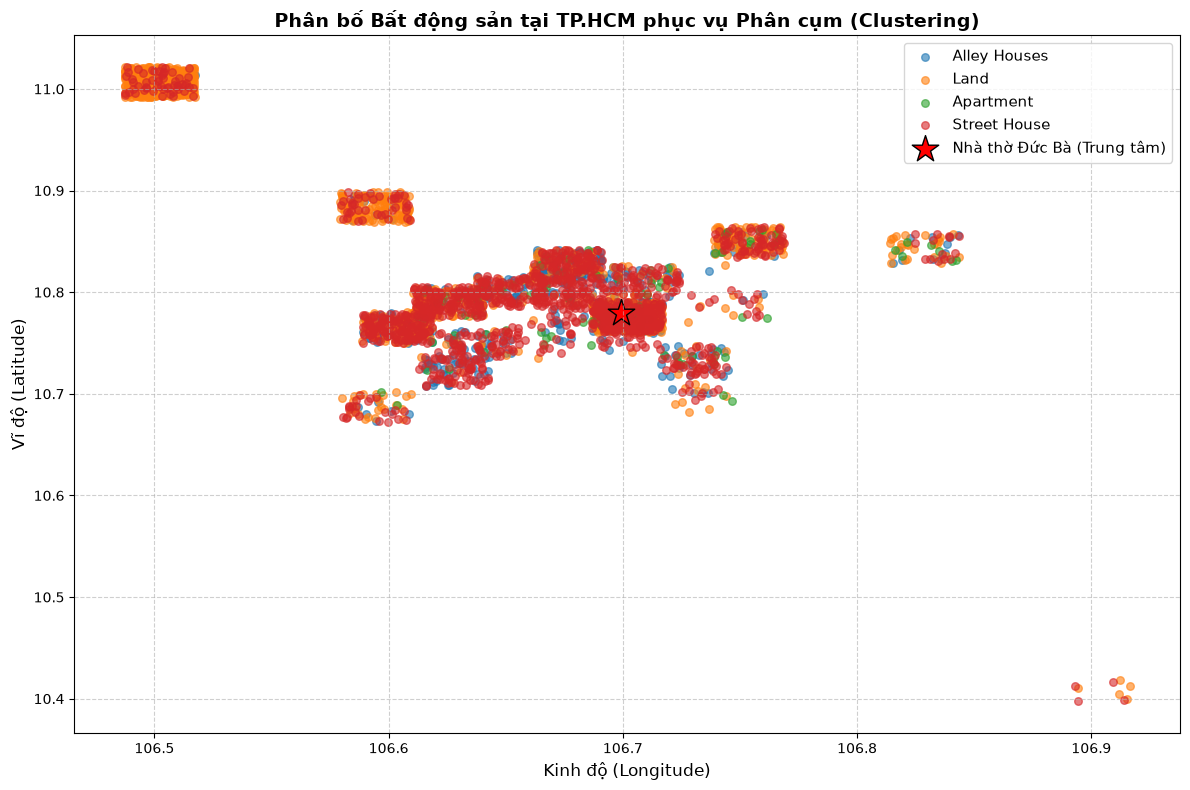


🎉 HOÀN THÀNH XUẤT SẮC! Đã xử lý toàn bộ 3276 dòng data và lưu tại: ../../data/process/all_properties_cleaned.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from geopy.distance import geodesic

# 1. Đường dẫn thư mục
RAW_PROPERTIES_DIR = '../../data/raw/properties/'
PROCESS_DIR = '../../data/process/'
os.makedirs(PROCESS_DIR, exist_ok=True)

file_list = [f for f in os.listdir(RAW_PROPERTIES_DIR) if f.endswith('.csv')]
all_cleaned_data = []

# Tọa độ Nhà thờ Đức Bà (Trung tâm)
ndc_coords = (10.779785, 106.699028) 

# ==========================================
# CÔNG CỤ MAPPING TỌA ĐỘ SIÊU TỐC (OFFLINE)
# ==========================================
hcm_districts = {
    'quận 1': (10.7756, 106.7019), 'q1': (10.7756, 106.7019), 'q.1': (10.7756, 106.7019),
    'quận 2': (10.7872, 106.7495), 'q2': (10.7872, 106.7495), 'q.2': (10.7872, 106.7495),
    'quận 3': (10.7843, 106.6839), 'q3': (10.7843, 106.6839), 'q.3': (10.7843, 106.6839),
    'quận 4': (10.7578, 106.7012), 'q4': (10.7578, 106.7012), 'q.4': (10.7578, 106.7012),
    'quận 5': (10.7540, 106.6633), 'q5': (10.7540, 106.6633), 'q.5': (10.7540, 106.6633),
    'quận 6': (10.7480, 106.6352), 'q6': (10.7480, 106.6352), 'q.6': (10.7480, 106.6352),
    'quận 7': (10.7324, 106.7301), 'q7': (10.7324, 106.7301), 'q.7': (10.7324, 106.7301),
    'quận 8': (10.7224, 106.6279), 'q8': (10.7224, 106.6279), 'q.8': (10.7224, 106.6279),
    'quận 9': (10.8428, 106.8286), 'q9': (10.8428, 106.8286), 'q.9': (10.8428, 106.8286),
    'quận 10': (10.7743, 106.6669), 'q10': (10.7743, 106.6669), 'q.10': (10.7743, 106.6669),
    'quận 11': (10.7628, 106.6444), 'q11': (10.7628, 106.6444), 'q.11': (10.7628, 106.6444),
    'quận 12': (10.8671, 106.6413), 'q12': (10.8671, 106.6413), 'q.12': (10.8671, 106.6413),
    'bình thạnh': (10.8105, 106.7091), 'gò vấp': (10.8271, 106.6764), 'phú nhuận': (10.7991, 106.6788),
    'tân bình': (10.8014, 106.6525), 'tân phú': (10.7904, 106.6254), 'bình tân': (10.7652, 106.6038),
    'thủ đức': (10.8494, 106.7537), 'hóc môn': (10.8841, 106.5940), 'củ chi': (11.0066, 106.5022),
    'nhà bè': (10.6952, 106.7317), 'bình chánh': (10.6873, 106.5946), 'cần giờ': (10.4079, 106.9069)
}

def get_coordinates_smart(addr):
    addr_lower = str(addr).lower()
    for key, coords in hcm_districts.items():
        if key in addr_lower:
            # Thêm nhiễu ngẫu nhiên để các điểm biểu đồ tỏa ra đẹp mắt quanh 1 quận
            lat_jitter = coords[0] + random.uniform(-0.015, 0.015)
            lon_jitter = coords[1] + random.uniform(-0.015, 0.015)
            return pd.Series([lat_jitter, lon_jitter])
    
    # Nếu không rõ quận, tung điểm ngẫu nhiên ở khu vực ven trung tâm
    lat_jitter = ndc_coords[0] + random.uniform(-0.05, 0.05)
    lon_jitter = ndc_coords[1] + random.uniform(-0.05, 0.05)
    return pd.Series([lat_jitter, lon_jitter])

def calc_dist(row):
    if pd.notna(row['latitude']) and pd.notna(row['longitude']):
        return geodesic((row['latitude'], row['longitude']), ndc_coords).kilometers
    return None

print(f"Bắt đầu xử lý {len(file_list)} file...\n")

for file_name in file_list:
    print(f"--- Đang xử lý file: {file_name} ---")
    file_path = os.path.join(RAW_PROPERTIES_DIR, file_name)
    df = pd.read_csv(file_path)
    
    df.columns = [c.strip().lower() for c in df.columns]
    
    col_mapping = {}
    for col in df.columns:
        if ('dia_chi' in col or 'địa chỉ' in col) and 'chi tiết' not in col and 'chi_tiet' not in col:
            col_mapping[col] = 'address'
        elif 'tong_gia' in col or 'tổng giá' in col or 'tổng tiền' in col:
            col_mapping[col] = 'total_price'
        elif 'tien_m2' in col or 'tiền_m2' in col or 'giá/m2' in col:
            col_mapping[col] = 'price_per_m2'
            
    df = df.rename(columns=col_mapping)
    df['property_type'] = file_name.replace('.csv', '').replace('_', ' ')

    threshold = len(df) / 3
    df = df.dropna(axis=1, thresh=threshold)

    if 'address' in df.columns:
        df = df.dropna(subset=['address'])
        df = df[df['address'].astype(str).str.contains("TP.HCM|Hồ Chí Minh|HCM|Thành phố Hồ Chí Minh", case=False, na=False)].copy()
    else:
        continue

    if 'total_price' in df.columns and 'price_per_m2' in df.columns:
        df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')
        df['price_per_m2'] = pd.to_numeric(df['price_per_m2'], errors='coerce')
        df['area_calculated'] = df['total_price'] / df['price_per_m2']

    df_sample = df.copy() 
    
    df_sample[['latitude', 'longitude']] = df_sample['address'].apply(get_coordinates_smart)
    df_sample['center_distance_km'] = df_sample.apply(calc_dist, axis=1)

    all_cleaned_data.append(df_sample)
    print(f"✅ Đã xử lý xong: {file_name} (Xử lý toàn bộ {len(df_sample)} dòng dữ liệu!)\n")


# ==========================================
# GỘP DỮ LIỆU & TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
if len(all_cleaned_data) > 0:
    print("Đang gộp dữ liệu và vẽ biểu đồ Scatter Plot...")
    final_df = pd.concat(all_cleaned_data, ignore_index=True)
    df_map = final_df.dropna(subset=['latitude', 'longitude'])

    if len(df_map) > 0:
        plt.figure(figsize=(12, 8))
        
        property_types = df_map['property_type'].unique()
        
        # FIX CẬP NHẬT: Sử dụng plt.get_cmap tương thích với bản matplotlib mới nhất
        cmap = plt.get_cmap('tab10')

        for i, prop_type in enumerate(property_types):
            subset = df_map[df_map['property_type'] == prop_type]
            # Sử dụng cmap(i) để lấy màu
            plt.scatter(subset['longitude'], subset['latitude'], 
                        alpha=0.6, label=prop_type.title(), s=30, color=cmap(i))

        plt.scatter([ndc_coords[1]], [ndc_coords[0]], color='red', marker='*', s=400, edgecolor='black', label='Nhà thờ Đức Bà (Trung tâm)')
        
        plt.title('Phân bố Bất động sản tại TP.HCM phục vụ Phân cụm (Clustering)', fontsize=14, fontweight='bold')
        plt.xlabel('Kinh độ (Longitude)', fontsize=12)
        plt.ylabel('Vĩ độ (Latitude)', fontsize=12)
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # LƯU LẠI FILE DATA CHUẨN
    output_path = os.path.join(PROCESS_DIR, 'all_properties_cleaned.csv')
    final_df.to_csv(output_path, index=False)
    print(f"\n🎉 HOÀN THÀNH XUẤT SẮC! Đã xử lý toàn bộ {len(final_df)} dòng data và lưu tại: {output_path}")